In [1]:
from qiskit.circuit import Parameter, QuantumCircuit, QuantumRegister, ClassicalRegister

from qiskit.quantum_info import Pauli, SparsePauliOp, Statevector, Operator
from scipy.optimize import minimize 
from qiskit.circuit.library import QFT
from qiskit import transpile
from qiskit.circuit.library import UnitaryGate

import random
import matplotlib.pyplot as plt
import scipy.linalg as scl
import numpy as np
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime.fake_provider import FakeKyiv
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

backend = AerSimulator()

# backend=FakeKyiv()
# sampler = Sampler(backend = backend)
pm = generate_preset_pass_manager(backend=backend,optimization_level=2)

In [2]:


nb_qubits = 3

N = 2**nb_qubits
m = np.zeros((N,N))
for j in range(N):
    if j == N-1:
        break
    else:
       m[j,j+1] = -1 

for j in range(N):
    if j == N-1:
        break
    else:
       m[j+1,j] = -1 
for j in range(N):
   m[j,j] = 2 
m[0] = np.array([1]+ [0]*(N-1))
m[1,0] = 0

b = np.array([0,0.25,0.25,0.25,0.25,0.5,0.5,0.5])
m

array([[ 1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  2., -1.,  0.,  0.,  0.,  0.,  0.],
       [ 0., -1.,  2., -1.,  0.,  0.,  0.,  0.],
       [ 0.,  0., -1.,  2., -1.,  0.,  0.,  0.],
       [ 0.,  0.,  0., -1.,  2., -1.,  0.,  0.],
       [ 0.,  0.,  0.,  0., -1.,  2., -1.,  0.],
       [ 0.,  0.,  0.,  0.,  0., -1.,  2., -1.],
       [ 0.,  0.,  0.,  0.,  0.,  0., -1.,  2.]])

In [3]:
d,u = np.linalg.eig(m)
k = np.max(d)/np.min(d)
dm = max(d)
# m = m/dm

In [4]:
np.linalg.det(m)



7.999999999999998

In [5]:
def U_b(nb_qubits):
    circ = QuantumCircuit(nb_qubits)
    circ.prepare_state(b)
    return circ
U = U_b(nb_qubits)
b = np.array(Statevector(U_b(nb_qubits)))
b

array([1.80411242e-16+6.93889390e-17j, 2.50000000e-01+5.13478149e-16j,
       2.50000000e-01-2.98372438e-16j, 2.50000000e-01-3.33066907e-16j,
       2.50000000e-01-6.66133815e-16j, 5.00000000e-01-6.10622664e-16j,
       5.00000000e-01+6.80011603e-16j, 5.00000000e-01+7.21644966e-16j])

In [6]:
def Hamiltonian(m):
    Ub = np.array(Operator(U_b(nb_qubits)))
    z = np.array([[1,0],
                 [0,-1]])
    I = np.array([[1,0],
                 [0,1]])
    def tensor(j,k,l):
        return np.kron(j,np.kron(k,l))
    M1 = (np.dot(np.dot(Ub,tensor(z,I,I)),np.conj(Ub.T))
          + np.dot(np.dot(Ub,tensor(I,z,I)),np.conj(Ub.T))
          +np.dot(np.dot(Ub,tensor(I,I,z)),np.conj(Ub.T)))
    M = 0.5*np.dot(np.dot(np.conj(m.T),(tensor(I,I,I) - M1/nb_qubits)),m)

    return M
A = Hamiltonian(m)

In [7]:
d,u = np.linalg.eig(A)
d

array([ 1.07137160e+01+4.60313931e-30j,  5.17089365e+00+4.54046984e-31j,
        4.37778335e+00-1.58546536e-30j,  2.55258866e+00+3.93905099e-30j,
        7.69885428e-01+6.47252844e-32j,  4.68684258e-01+2.35468363e-30j,
        1.06162203e-01-7.20815494e-31j, -1.90838462e-16-1.22075630e-30j])

[0.52822308 0.40519007 0.48765494 0.56605484 0.25056377 0.60720049
 0.53942809 0.61184558 0.99554639 0.74489715 0.81785207 0.25282619
 0.41243963 0.11381233 0.76354501 0.12637757 0.54608607 0.65329402
 0.20654193 0.89865501 0.5440122  0.26823429 0.24008469 0.44891939
 0.56125941 0.05261654 0.02638421 0.06759133 0.32614957 0.39266204
 0.19674497 0.49752617 0.77267437 0.36766943 0.13459572 0.19071781
 0.32369167 0.16330848 0.97698898 0.77080536 0.9932332  0.01020086
 0.46480411 0.36827222 0.85136601 0.56377214 0.76375202 0.70418403
 0.51832791 0.95456412 0.07161198 0.87443302 0.80597287 0.3618098 ]


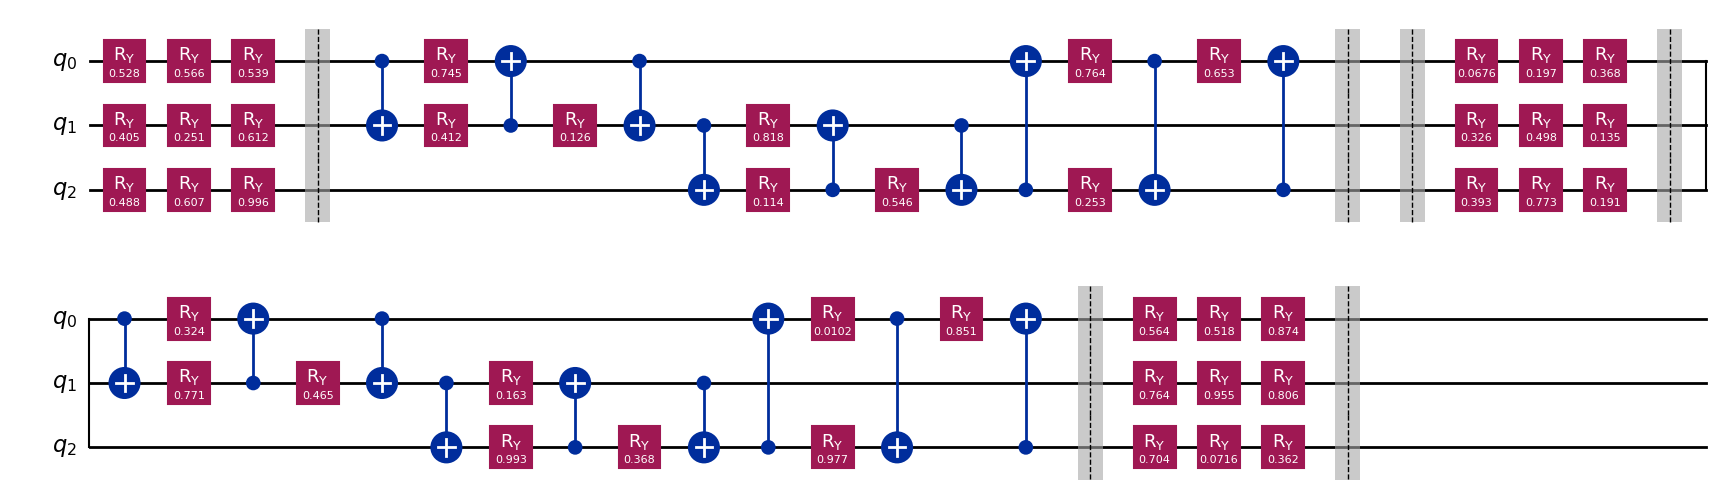

In [8]:

def ansatz(Parameters):
    qc = QuantumCircuit(N)
    for d in range(depth):
        param1=Parameters[d*9*N:(d+1)*(9*N)]
        for q in range(N):
            qc.ry(param1[q],qubits[q])
            qc.ry(param1[q+N],qubits[q])
            qc.ry(param1[q+2*N],qubits[q])
        qc.barrier()
        for q in range(N):
            qc.cx(qubits[q], qubits[(q+1)% N])
            qc.ry(param1[q+3*N],qubits[q])
            qc.ry(param1[q+4*N],qubits[(q+1)% N])
            qc.cx(qubits[(q+1)% N], qubits[q])
            qc.ry(param1[q+5*N],qubits[(q+1)% N])
            qc.cx(qubits[q], qubits[(q+1)% N])
        qc.barrier()
        if d==depth-1:
            for q in range(N):
                qc.ry(param1[q+6*N],qubits[q])
                qc.ry(param1[q+7*N],qubits[q])
                qc.ry(param1[q+8*N],qubits[q])
        qc.barrier()
    
    return qc

nb_qubits=3
depth=2
qubits=list(range(nb_qubits))
N=len(qubits)
nb_params=int(9*N*depth)

# Parameters = np.array([random.random() for _ in range(0, nb_params)])
Parameters = np.array([0.52822308, 0.40519007, 0.48765494, 0.56605484, 0.25056377,
       0.60720049, 0.53942809, 0.61184558, 0.99554639, 0.74489715,
       0.81785207, 0.25282619, 0.41243963, 0.11381233, 0.76354501,
       0.12637757, 0.54608607, 0.65329402, 0.20654193, 0.89865501,
       0.5440122 , 0.26823429, 0.24008469, 0.44891939, 0.56125941,
       0.05261654, 0.02638421, 0.06759133, 0.32614957, 0.39266204,
       0.19674497, 0.49752617, 0.77267437, 0.36766943, 0.13459572,
       0.19071781, 0.32369167, 0.16330848, 0.97698898, 0.77080536,
       0.9932332 , 0.01020086, 0.46480411, 0.36827222, 0.85136601,
       0.56377214, 0.76375202, 0.70418403, 0.51832791, 0.95456412,
       0.07161198, 0.87443302, 0.80597287, 0.3618098 ])
print(Parameters)
ansatz(Parameters).draw("mpl")


In [9]:

U1=scl.expm(2**0*2*np.pi*1j*A) 
U2=scl.expm(2**1*2*np.pi*1j*A) 
U3=scl.expm(2**2*2*np.pi*1j*A) 
U4=scl.expm(2**3*2*np.pi*1j*A) 
U5=scl.expm(2**4*2*np.pi*1j*A) 
U6=scl.expm(2**5*2*np.pi*1j*A) 
U7=scl.expm(2**6*2*np.pi*1j*A) 
U8=scl.expm(2**7*2*np.pi*1j*A)
 
u1gate = UnitaryGate(U1)
u2gate = UnitaryGate(U2)
u3gate=UnitaryGate(U3)
u4gate=UnitaryGate(U4)
u5gate=UnitaryGate(U5)
u6gate=UnitaryGate(U6)
u7gate=UnitaryGate(U7)
u8gate=UnitaryGate(U8)


C_u1gate=u1gate.control()
C_u2gate=u2gate.control()
C_u3gate=u3gate.control()
C_u4gate=u4gate.control()
C_u5gate=u5gate.control()
C_u6gate=u6gate.control()
C_u7gate=u7gate.control()
C_u8gate=u8gate.control()
    

In [11]:

def circ(parameters):
    x=QuantumRegister(11)
    c=ClassicalRegister(8)
    circuit = QuantumCircuit(x,c)
    phi=parameters
    circuit=circuit.compose(ansatz(parameters),x[8:11])
    circuit.h(x[0:8]) 
    circuit.append(C_u1gate, [x[0],x[8],x[9],x[10]])    
    circuit.append(C_u2gate, [x[1],x[8],x[9],x[10]])    
    circuit.append(C_u3gate, [x[2],x[8],x[9],x[10]])    
    circuit.append(C_u4gate, [x[3],x[8],x[9],x[10]]) 
    circuit.append(C_u5gate, [x[4],x[8],x[9],x[10]])
    circuit.append(C_u6gate, [x[5],x[8],x[9],x[10]])    
    circuit.append(C_u7gate, [x[6],x[8],x[9],x[10]]) 
    circuit.append(C_u8gate, [x[7],x[8],x[9],x[10]])
    circuit &= QFT(num_qubits = 8, approximation_degree = 0, do_swaps = True, 
                   inverse = True, insert_barriers = False, name='qft')
    circuit.measure(x[0:8],c)       
    return circuit

/tmp/ipykernel_2707284/8292215.py:16: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  circuit &= QFT(num_qubits = 8, approximation_degree = 0, do_swaps = True,


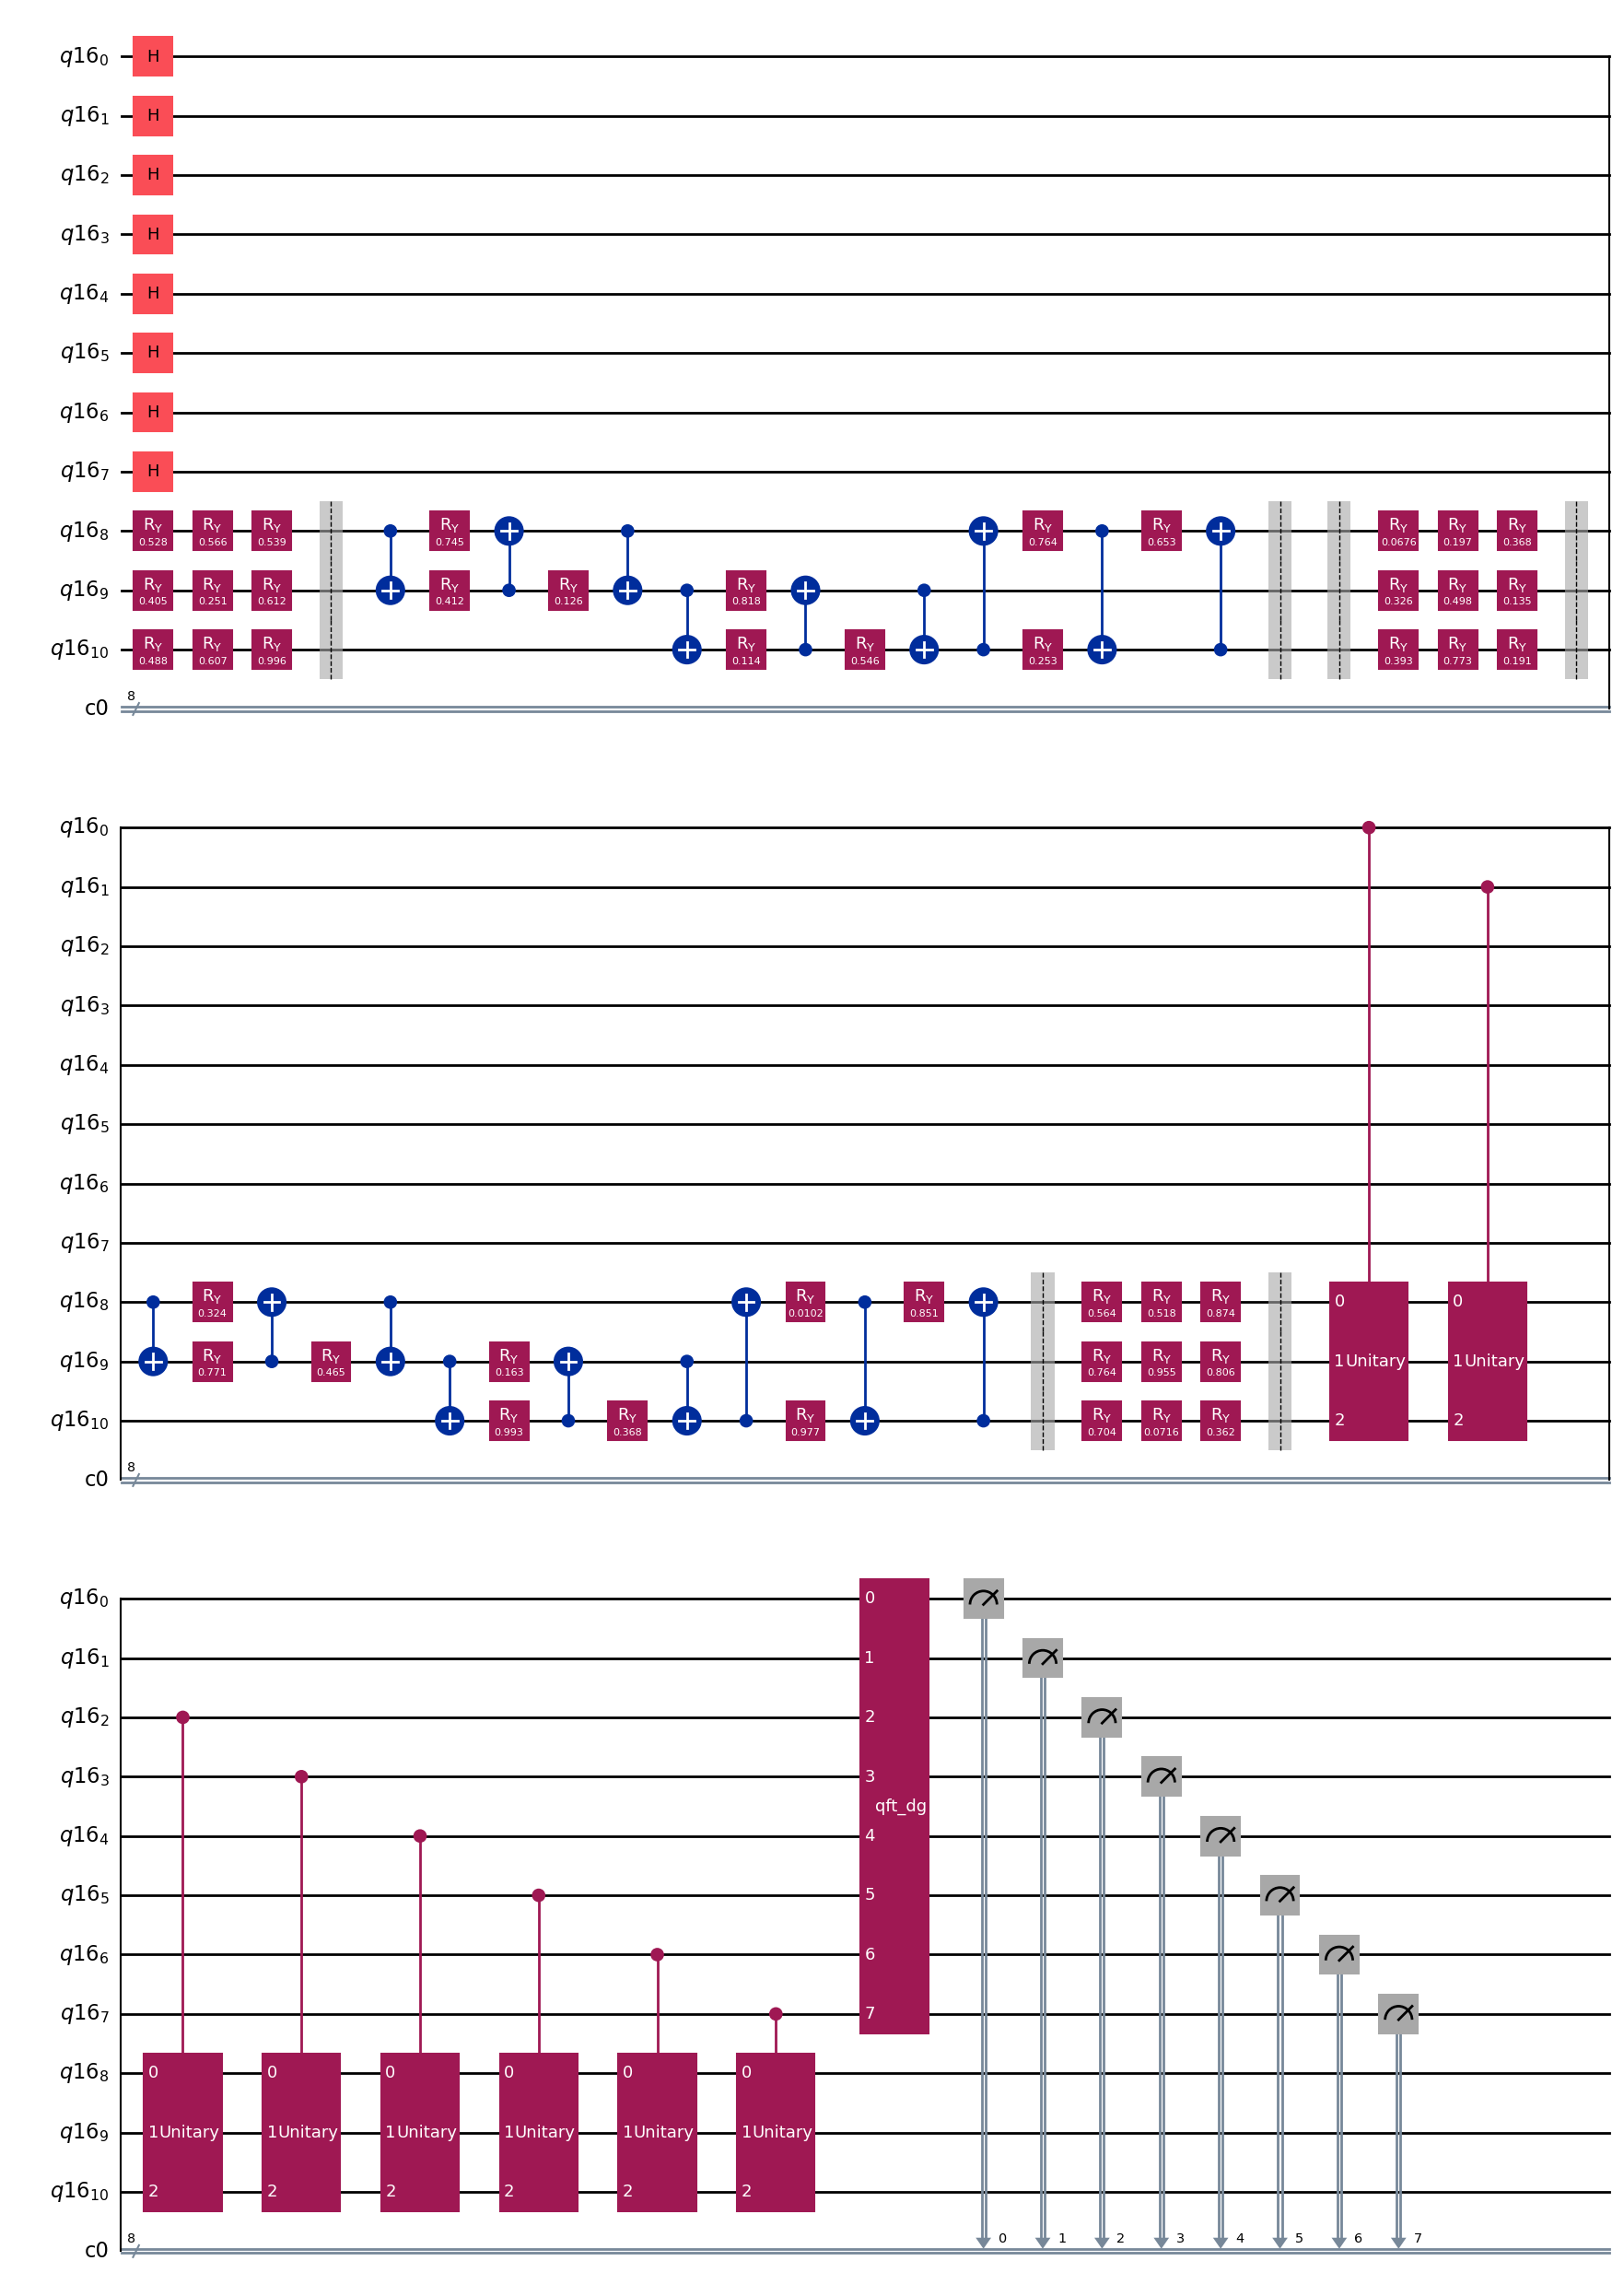

In [12]:
circ(Parameters).draw("mpl") 

In [13]:
shots = 100000
def cost(Parameters):
    job = backend.run(pm.run(circ(Parameters)),shots = shots).result()
    result = job.get_counts(0)
    if '00000000'not in result: 
        res = 1
    else:
        res = 1 - result['00000000']/shots
    return res
# cost(parameters)


In [14]:
import warnings
warnings.filterwarnings("ignore")
from qiskit_algorithms.optimizers import SPSA
def save(nfev, Parameters, cost, learning_rate, trust_region):
    
    global Cost,Params
    Cost.append(cost)
    Params.append(Parameters)
    print(nfev, cost)
Cost = []
Params = []
spsa = SPSA(maxiter=2000, callback =save)
spsa.minimize(cost, Parameters)
# print(Cost)
    

3 0.98046
6 0.9664
9 0.8995
12 0.93667
15 0.7734300000000001
18 0.7821899999999999
21 0.99998
24 0.9659
27 0.92114
30 0.83433
33 0.9886
36 0.85432
39 0.78608
42 0.98901
45 0.9640299999999999
48 0.85238
51 0.97026
54 0.8589
57 0.8515900000000001
60 0.77782
63 0.79865
66 0.99941
69 0.99936
72 0.9991
75 0.98513
78 0.97347
81 0.96658
84 0.96635
87 0.94412
90 0.92175
93 0.90689
96 0.87824
99 0.8781
102 0.93746
105 0.93683
108 0.91304
111 0.91076
114 0.82315
117 0.56882
120 0.92114
123 0.92268
126 0.91011
129 0.86148
132 0.51136
135 0.91641
138 0.84912
141 0.89578
144 0.99333
147 0.98179
150 0.98096
153 0.79325
156 0.8137099999999999
159 0.86254
162 0.95547
165 0.94812
168 0.77562
171 0.97793
174 0.95583
177 0.88789
180 0.76908
183 0.87226
186 0.97939
189 0.9563200000000001
192 0.94987
195 0.7017599999999999
198 0.81945
201 0.79645
204 0.80461
207 0.80047
210 0.99905
213 0.99637
216 0.99618
219 0.95514
222 0.86837
225 0.72338
228 0.9172899999999999
231 0.90176
234 0.83609
237 0.83204
240 0.9

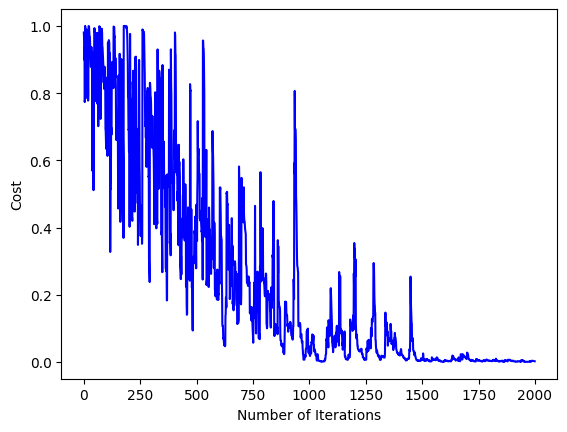

In [15]:
plt.plot(range(len(Cost)), Cost,'b')
# plt.axis([0, 100, 0, 0.0007])
plt.xlabel('Number of Iterations')
plt.ylabel('Cost')
plt.show()


In [16]:
x_exact = np.linalg.solve(m,b)
x_exact = x_exact/np.linalg.norm(x_exact)

In [17]:
e = []
F =[ ]
norm_e = []
for k in range(len(Params)):
    state = np.array(Statevector(ansatz(Params[k])))
    psi = np.dot(m,state)
    Psi = psi/np.linalg.norm(psi)
    norm = np.dot(state,x_exact)
    e.append(state - x_exact/norm)
    # f = abs(np.dot(Psi,b))**2
    f = abs(np.dot(state,x_exact))**2
    F.append(f)

for v in e:
    norm_e.append(float(np.linalg.norm(v)))

Text(0.5, 0, 'Iteration')

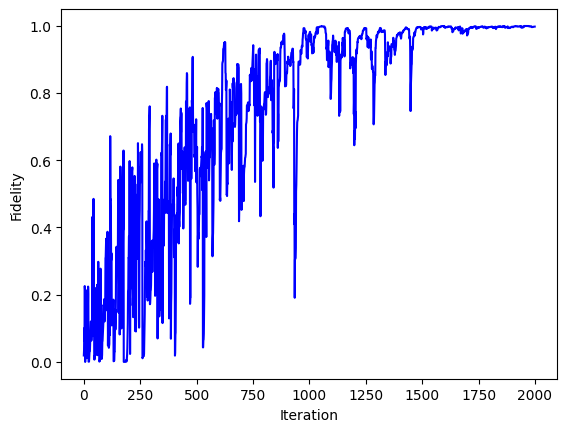

In [18]:
# plt.scatter(range(len(F)),F)
plt.plot(range(len(F)),F,'b')
# plt.axis([0, 100, 0, 0.0007])
plt.ylabel('Fidelity')
plt.xlabel('Iteration')


In [19]:
norm_e[np.argmax(F)]

0.019043381019775416

In [20]:
np.linalg.norm(np.real(e[np.argmax(F)]))

0.019043381019775416

Text(0.5, 0, 'Iteration')

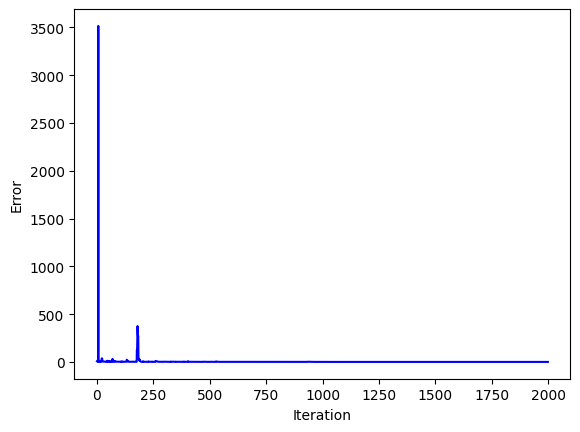

In [21]:
# plt.scatter(range(len(F)),F)
plt.plot(range(len(norm_e)),norm_e,'b')
# plt.axis([0, 100, 0, 0.0007])
plt.ylabel('Error')
plt.xlabel('Iteration')

In [22]:
X_opt  = np.array(Statevector(ansatz(Params[-1])))
psi = m@X_opt
psi = psi/np.linalg.norm(psi)

In [23]:
abs(np.array(e[-1]))

array([0.00108976, 0.01918755, 0.00469482, 0.0376366 , 0.00408184,
       0.0197097 , 0.00398034, 0.01243632])

In [25]:
print(F)

[0.019160567701058544, 0.03403006068448896, 0.10050926215182981, 0.062103358204867065, 0.22567181745602444, 0.21522064590183473, 8.088930197691686e-08, 0.03400102835997261, 0.078441273129135, 0.16461071292894347, 0.011931212562987972, 0.14506292650674066, 0.21265110893976436, 0.01110443770791133, 0.03577767045052819, 0.1464131907135289, 0.03023743674380136, 0.14156395173979713, 0.14818299678595992, 0.2241048024647642, 0.2016237047579575, 0.0007400979721535817, 0.0007338793361726394, 0.0007445566696794191, 0.015786305257470216, 0.026529365901803072, 0.03359155697209541, 0.033598333592568516, 0.05619880175676823, 0.07767020594326218, 0.09497138491097465, 0.12043330259492833, 0.12025127090164053, 0.06331268749627404, 0.06431021267449535, 0.08711817541633543, 0.0886404047749483, 0.1765387198709496, 0.4313764605696924, 0.07730999521738081, 0.07697858434109761, 0.08978524687837194, 0.13840756100374452, 0.4851470237390152, 0.08386592938157213, 0.1502914581255726, 0.10313089099058365, 0.006811